In [1]:
!pip install scikit-posthocs

In [4]:
#Bibliotecas

import pandas as pd
from scipy.stats import kruskal
import matplotlib.pyplot as plt
import scikit_posthocs as sp
from scipy import stats
import numpy as np
from scikit_posthocs import posthoc_dunn
import pandas as pd
import seaborn as sns

df = pd.read_csv(
    "Trabalho_Ergonomia(DADOS).csv",
    sep=";",
    encoding="latin1",
    decimal=","
)

In [5]:
#Análise descritiva e comparativa com todos os dados

coluna_grupo = "Local"
coluna_valor = "Medição  (µT)"

analise_completa = df.groupby(coluna_grupo)[coluna_valor].agg(
    count="count",
    mean="mean",
    median="median",
    std="std",
    var="var",
    min="min",
    max="max"
)

analise_completa["amplitude"] = analise_completa["max"] - analise_completa["min"]
analise_completa["cv_%"] = (analise_completa["std"] / analise_completa["mean"]) * 100

# Ordenar pela média
analise_completa = analise_completa.sort_values(by="mean", ascending=False)

print("\nANÁLISE 1 — COM TODOS OS DADOS")
print(analise_completa.round(4))


ANÁLISE 1 — COM TODOS OS DADOS
          count    mean  median     std      var     min      max  amplitude  \
Local                                                                          
PT9CTBC    9832  6.5812  6.3455  3.2629  10.6462  1.2544  15.2822    14.0278   
PT10BE12  22697  1.5268  1.4231  0.3298   0.1088  0.9224   2.4221     1.4998   
PT6CB3    22073  1.3498  1.2915  0.2152   0.0463  0.9758   2.0314     1.0556   
PT5A3     26601  1.2195  1.1767  0.1174   0.0138  1.0743   1.5266     0.4523   
PT11J1     7429  1.1858  1.1823  0.0540   0.0029  1.0079   1.4479     0.4400   
PT2B7      3849  1.1796  1.1743  0.0569   0.0032  1.0233   1.6003     0.5770   
PT1M4      4904  1.1741  1.1385  0.1272   0.0162  0.2576   1.8130     1.5554   
PT7JO3     9812  1.1666  1.1677  0.0379   0.0014  1.0445   1.2843     0.2398   
PT4A2     12821  1.1382  1.1306  0.0582   0.0034  0.9574   1.4697     0.5123   
PT3MM15   14481  1.1299  1.1381  0.0424   0.0018  0.9757   1.3937     0.4179   
PT8BM16 

**Vou usar o critério mais comum: IQR (Intervalo Interquartil) dentro de cada grupo.**

**Um valor é considerado discrepante se:**

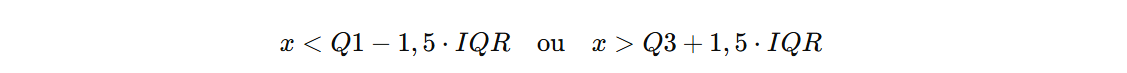

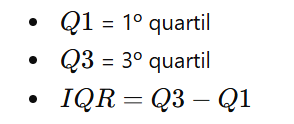

Isso é importante porque os outliers serão removidos dentro de cada Local, e não no conjunto inteiro.

In [ ]:
#Função para remover outliers por grupo usando IQR
def remover_outliers_iqr(grupo):
    q1 = grupo[coluna_valor].quantile(0.25)
    q3 = grupo[coluna_valor].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    grupo_filtrado = grupo[
        (grupo[coluna_valor] >= limite_inferior) &
        (grupo[coluna_valor] <= limite_superior)
    ]
    return grupo_filtrado

In [ ]:
#Remover outliers por Local

df_sem_outliers = df.groupby(coluna_grupo, group_keys=False).apply(remover_outliers_iqr)

In [ ]:
#Análise descritiva e comparativa sem outliers

analise_sem_outliers = df_sem_outliers.groupby(coluna_grupo)[coluna_valor].agg(
    count="count",
    mean="mean",
    median="median",
    std="std",
    var="var",
    min="min",
    max="max"
)

analise_sem_outliers["amplitude"] = analise_sem_outliers["max"] - analise_sem_outliers["min"]
analise_sem_outliers["cv_%"] = (analise_sem_outliers["std"] / analise_sem_outliers["mean"]) * 100

# Ordenar pela média
analise_sem_outliers = analise_sem_outliers.sort_values(by="mean", ascending=False)

print("\nANÁLISE 2 — SEM VALORES DISCREPANTES")
print(analise_sem_outliers.round(4))

In [ ]:
#Quantidade removida por grupo
total_por_grupo = df.groupby(coluna_grupo)[coluna_valor].count()
total_sem_outliers = df_sem_outliers.groupby(coluna_grupo)[coluna_valor].count()

comparacao_remocao = pd.DataFrame({
    "n_total": total_por_grupo,
    "n_sem_outliers": total_sem_outliers
})

comparacao_remocao["outliers_removidos"] = (
    comparacao_remocao["n_total"] - comparacao_remocao["n_sem_outliers"]
)

comparacao_remocao["pct_removido_%"] = (
    comparacao_remocao["outliers_removidos"] / comparacao_remocao["n_total"] * 100
)

comparacao_remocao = comparacao_remocao.sort_values(
    by="outliers_removidos",
    ascending=False
)

print("\nQUANTIDADE DE VALORES DISCREPANTES REMOVIDOS POR GRUPO")
print(comparacao_remocao.round(4))

In [ ]:
plt.figure(figsize=(12, 6))
df_sem_outliers.boxplot(column=coluna_valor, by=coluna_grupo, grid=False, showfliers=False)
plt.title("Boxplot da Medição (µT) por Local - Sem valores discrepantes")
plt.suptitle("")
plt.xlabel("Local")
plt.ylabel("Medição (µT)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
#REMOVER PT9CTBC
df_filtrado = df[df["Local"] != "PT9CTBC"].copy()

#FUNÇÃO PARA REMOVER OUTLIERS POR GRUPO
def remover_outliers_iqr(grupo):
    q1 = grupo["Medição  (µT)"].quantile(0.25)
    q3 = grupo["Medição  (µT)"].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    return grupo[(grupo["Medição  (µT)"] >= limite_inferior) &
                 (grupo["Medição  (µT)"] <= limite_superior)]

#REMOVER OUTLIERS POR GRUPO
df_sem_outliers = df_filtrado.groupby("Local", group_keys=False).apply(remover_outliers_iqr)

#ORDENAR PELA MEDIANA
ordem = df_sem_outliers.groupby("Local")["Medição  (µT)"].median().sort_values().index

#PREPARAR DADOS ORDENADOS (SEM OUTLIERS)
dados_ordenados = [
    df_sem_outliers[df_sem_outliers["Local"] == local]["Medição  (µT)"]
    for local in ordem
]

#GRÁFICO ÚNICO
plt.figure(figsize=(14, 8))
plt.boxplot(
    dados_ordenados,
    tick_labels=ordem,
    showfliers=False,  # ← SEM DISCREPANTES
    patch_artist=True,  # ← CAIXAS COLORIDAS
    notch=True  # ← MEDIANA MARCADA
)

plt.title("Boxplot da Medição (µT) por Local\n(Sem PT9CTBC e Sem Outliers)",
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Local", fontsize=12, fontweight='bold')
plt.ylabel("Medição (µT)", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#RESUMO
print(f"Locais analisados: {len(ordem)}")
print(f"Total de medições (sem outliers): {len(df_sem_outliers)}")
print(f"Ordem das medianas:\n{ordem.tolist()}")

In [ ]:
 #TESTE KRUSKAL-WALLIS (SEM OUTLIERS)
print("="*70)
print("TESTE KRUSKAL-WALLIS (SEM OUTLIERS)")
print("="*70)

# Executar teste
statistic, p_value = stats.kruskal(*dados_ordenados)
print(f"Estatística H: {statistic:.4f}")
print(f"p-valor: {p_value:.4f}")

if p_value < 0.05:
    print("REJEITA H0: Há diferenças significativas entre os grupos!")
else:
    print("NÃO REJEITA H0: Não há diferenças significativas entre os grupos.")

print(f"Grupos testados: {len(dados_ordenados)}")
print(f"Amostras totais: {sum(len(d) for d in dados_ordenados)}")
print()

#GRÁFICO COM RESULTADO DO TESTE
plt.figure(figsize=(15, 9))

#Boxplot principal
box_plot = plt.boxplot(
    dados_ordenados,
    tick_labels=ordem,
    showfliers=False,
    patch_artist=True,
    notch=True,
    labels=ordem
)

#Colorir caixas
colors = plt.cm.Set3(np.linspace(0, 1, len(ordem)))
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

#Título com resultado do teste
if p_value < 0.05:
    resultado = f"p = {p_value:.4f}* (diferenças significativas)"
else:
    resultado = f"p = {p_value:.4f} (sem diferenças significativas)"

plt.title(f"Boxplot da Medição (µT) por Local\n"
          f"(Sem PT9CTBC e Sem Outliers) | Kruskal-Wallis: H={statistic:.2f}, {resultado}",
          fontsize=14, fontweight='bold', pad=20)

plt.xlabel("Local", fontsize=12, fontweight='bold')
plt.ylabel("Medição (µT)", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')

#Legenda do teste
plt.text(0.02, 0.98, '*p < 0.05', transform=plt.gca().transAxes,
         fontsize=12, fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

plt.tight_layout()
plt.show()

#RESUMO FINAL
print("RESUMO POR LOCAL:")
resumo = df_sem_outliers.groupby("Local")["Medição  (µT)"].agg(['count', 'median', 'mean']).round(2)
print(resumo)

In [ ]:
print("="*80)
print("PÓS-TESTE DUNN (Bonferroni)")
print("="*80)

#Preparar DataFrame para Dunn (dados SEM outliers)
dados_long = []
for local in ordem:
    valores = df_sem_outliers[df_sem_outliers["Local"] == local]["Medição  (µT)"].dropna()
    for valor in valores:
        dados_long.append({'Local': local, 'Medição': valor})

df_teste = pd.DataFrame(dados_long)

#Executar Dunn
dunn_matrix = posthoc_dunn(df_teste, val_col='Medição', group_col='Local', p_adjust='bonferroni')

print("Tabela Dunn (p-ajustados):")
print(dunn_matrix.round(4))
print()

#Pares significativos
significativos = dunn_matrix[dunn_matrix < 0.05].stack()
if len(significativos) > 0:
    print("PARES SIGNIFICATIVOS (p < 0.05):")
    for (g1, g2), pval in significativos.items():
        print(f"  {g1} ↔ {g2}: p = {pval:.4f}")
else:
    print("Nenhum par significativo.")

#GRÁFICO HEATMAP DA MATRIZ DUNN
plt.figure(figsize=(12, 10))
mask = dunn_matrix >= 0.05  #Máscara para não significativos

sns.heatmap(dunn_matrix,
            annot=True, fmt='.3f', cmap='RdYlBu_r',
            center=0.05, square=True,
            linewidths=0.5, cbar_kws={'label': 'p-valor ajustado'},
            mask=mask)

plt.title("Matriz de Pós-teste Dunn\n(Valores < 0.05 = Diferenças Significativas)",
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Local", fontsize=12, fontweight='bold')
plt.ylabel("Local", fontsize=12, fontweight='bold')

#Destacar diagonal
for spine in plt.gca().spines.values():
    spine.set_linewidth(2)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()